In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load dataset
df = pd.read_csv("Border_crossing_entry_data.csv")

# Initial Inspection
print("\nShape of dataset:", df.shape)
print("\nColumns:", df.columns)
print("\nInfo:")
df.info()



Shape of dataset: (11839, 10)

Columns: Index(['Port Name', 'State', 'Port Code', 'Border', 'Date', 'Measure', 'Value',
       'Latitude', 'Longitude', 'Point'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11839 entries, 0 to 11838
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Port Name  11839 non-null  object 
 1   State      11839 non-null  object 
 2   Port Code  11839 non-null  int64  
 3   Border     11839 non-null  object 
 4   Date       11839 non-null  object 
 5   Measure    11839 non-null  object 
 6   Value      11839 non-null  int64  
 7   Latitude   11839 non-null  float64
 8   Longitude  11839 non-null  float64
 9   Point      11839 non-null  object 
dtypes: float64(2), int64(2), object(6)
memory usage: 925.1+ KB


In [37]:

# Drop duplicates
df.drop_duplicates(inplace=True)

# Handle Missing Values
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# Drop rows with any missing values
df.dropna(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())




Missing Values Before Cleaning:
Port Name    0
State        0
Port Code    0
Border       0
Date         0
Measure      0
Value        0
Latitude     0
Longitude    0
Point        0
dtype: int64

Missing Values After Cleaning:
Port Name    0
State        0
Port Code    0
Border       0
Date         0
Measure      0
Value        0
Latitude     0
Longitude    0
Point        0
dtype: int64



Outlier Detection for 'Value':
Q1: 134.0, Q3: 4381.800000000001, IQR: 4247.800000000001
Lower Bound: -6237.700000000002, Upper Bound: 10753.500000000004
Number of Outliers: 2604

Shape After Outlier Removal: (9235, 10)

Stats Summary After Outlier Removal:
         Port Code         Value     Latitude    Longitude
count  9235.000000   9235.000000  9235.000000  9235.000000
mean   2407.532539   1342.300379    45.261491   -98.255426
std    1288.775932   2233.102017     7.347792    18.986944
min     101.000000      0.000000    25.952000  -141.001000
25%     901.000000     49.000000    45.006000  -112.788000
50%    3017.000000    303.000000    48.997000  -100.928000
75%    3403.000000   1538.000000    49.000000   -79.056000
max    3814.000000  10736.000000    62.615000   -66.980000

Missing Values After Cleaning:
Port Name    0
State        0
Port Code    0
Border       0
Date         0
Measure      0
Value        0
Latitude     0
Longitude    0
Point        0
dtype: int64


Text(0.5, 1.0, "Boxplot of 'Value' After Outlier Removal")

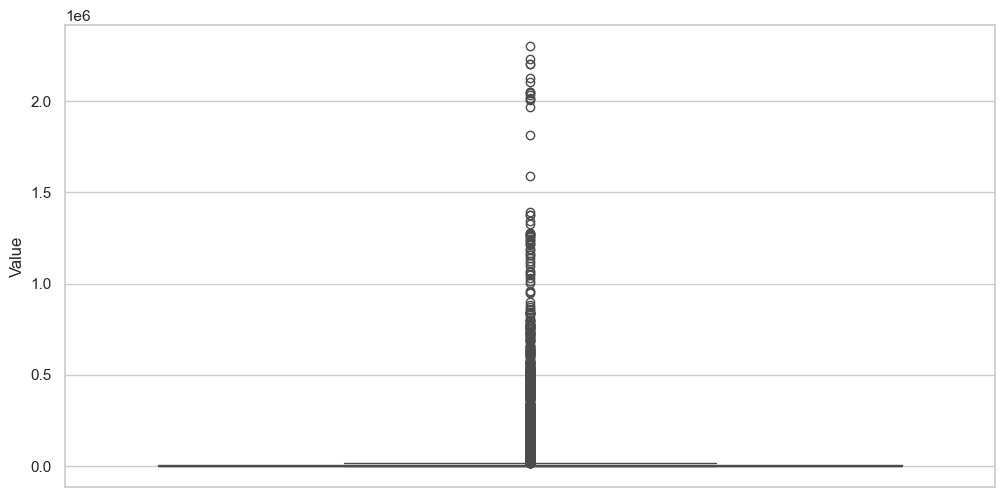

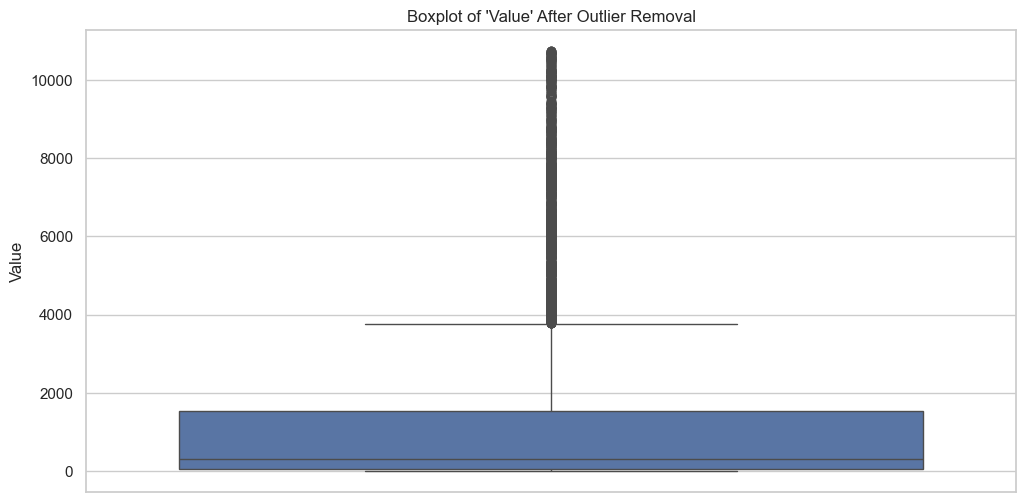

In [38]:
# to show the outlier
plt.figure(figsize=(12, 6))
sns.boxplot(y="Value", data=df)
# Outlier Detection and Removal using IQR for 'Value'
Q1 = df['Value'].quantile(0.3)
Q3 = df['Value'].quantile(0.7)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Print outlier info
print("\nOutlier Detection for 'Value':")
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(f"Number of Outliers: {len(df[(df['Value'] < lower_bound) | (df['Value'] > upper_bound)])}")
# Remove outliers
df_no_outliers = df[(df['Value'] >= lower_bound) & (df['Value'] <= upper_bound)]

# Summary after outlier removal
print("\nShape After Outlier Removal:", df_no_outliers.shape)
print("\nStats Summary After Outlier Removal:")
print(df_no_outliers.describe())
print("\nMissing Values After Cleaning:")
print(df_no_outliers.isnull().sum())

plt.figure(figsize=(12, 6))
sns.boxplot(y="Value", data=df_no_outliers)
plt.title("Boxplot of 'Value' After Outlier Removal")



In [39]:

# Visualizations
sns.set(style="whitegrid")




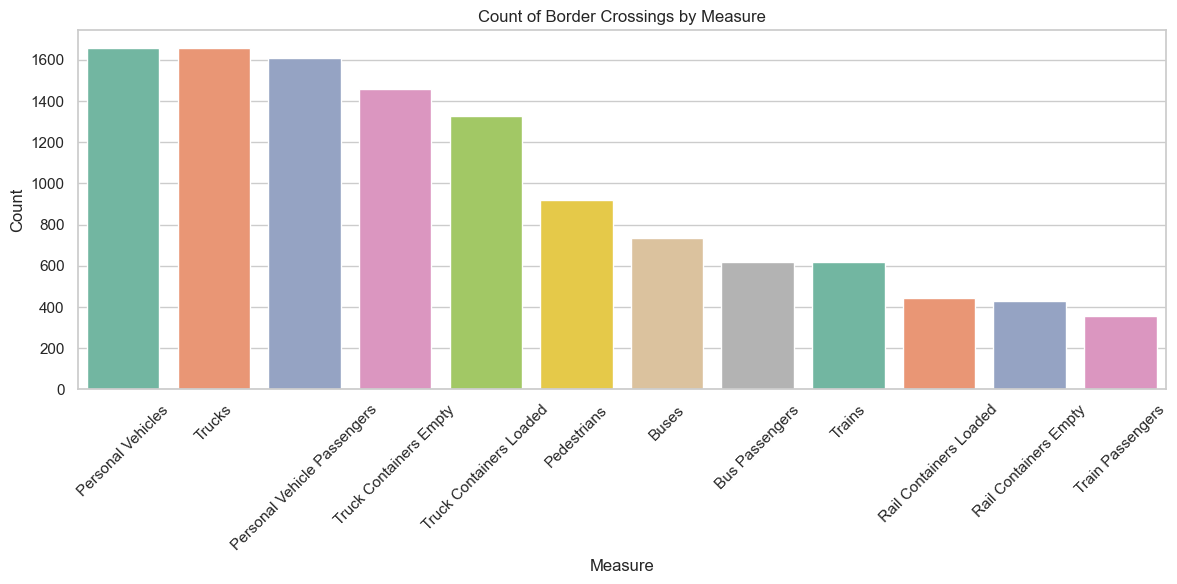

In [40]:

# 2. Measure-wise Crossing Count
measure_count = df['Measure'].value_counts().reset_index()
measure_count.columns = ['Measure', 'Count']
plt.figure(figsize=(12, 6))
sns.barplot(x='Measure', y='Count', data=measure_count, palette='Set2')
plt.title("Count of Border Crossings by Measure")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


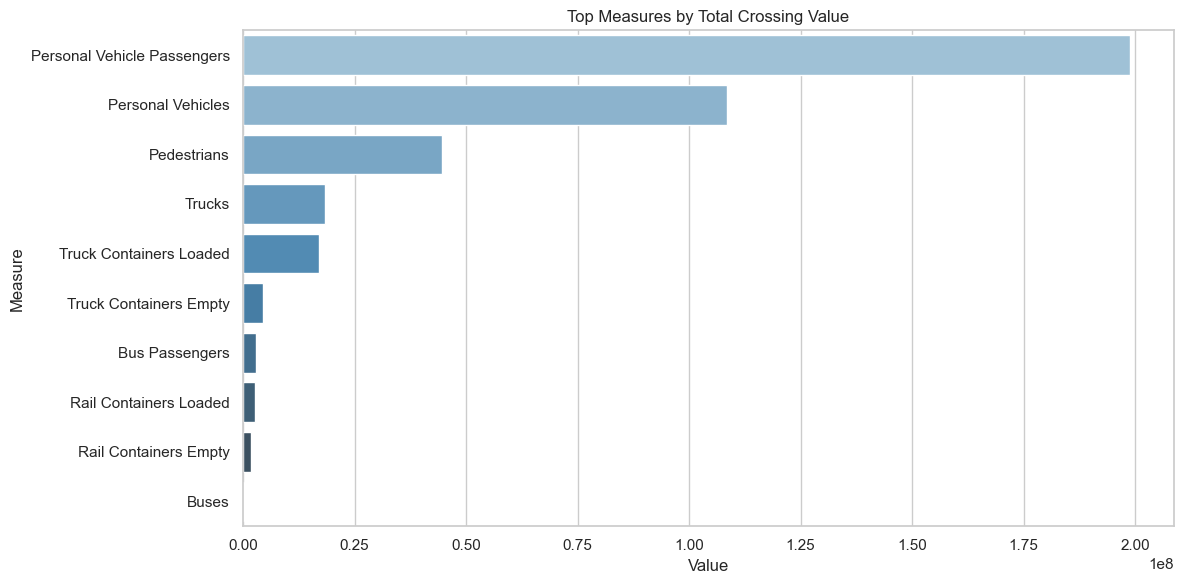

In [41]:

# 3. Top Measures by Value
top_measures = df.groupby('Measure')['Value'].sum().nlargest(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Value', y='Measure', data=top_measures, palette='Blues_d')
plt.title("Top Measures by Total Crossing Value")
plt.tight_layout()
plt.show()


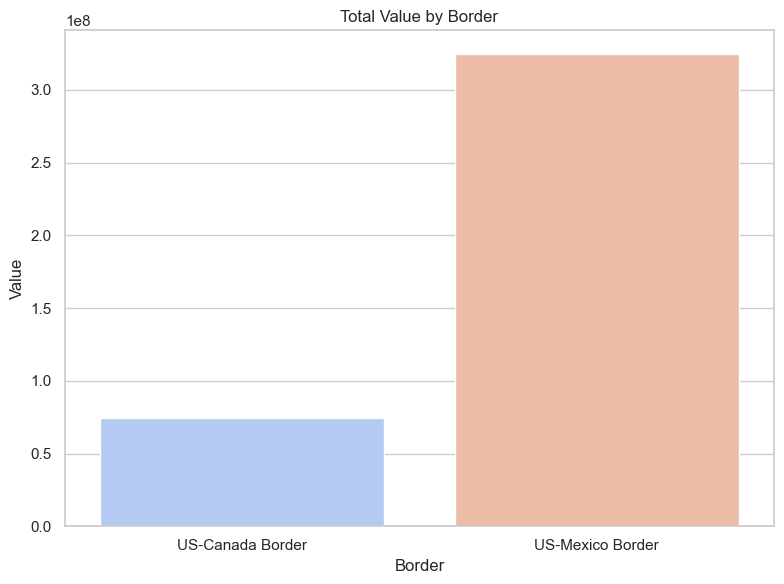

In [42]:

# 4. Border-wise Value
border_value = df.groupby('Border')['Value'].sum().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(x='Border', y='Value', data=border_value, palette='coolwarm')
plt.title("Total Value by Border")
plt.tight_layout()
plt.show()


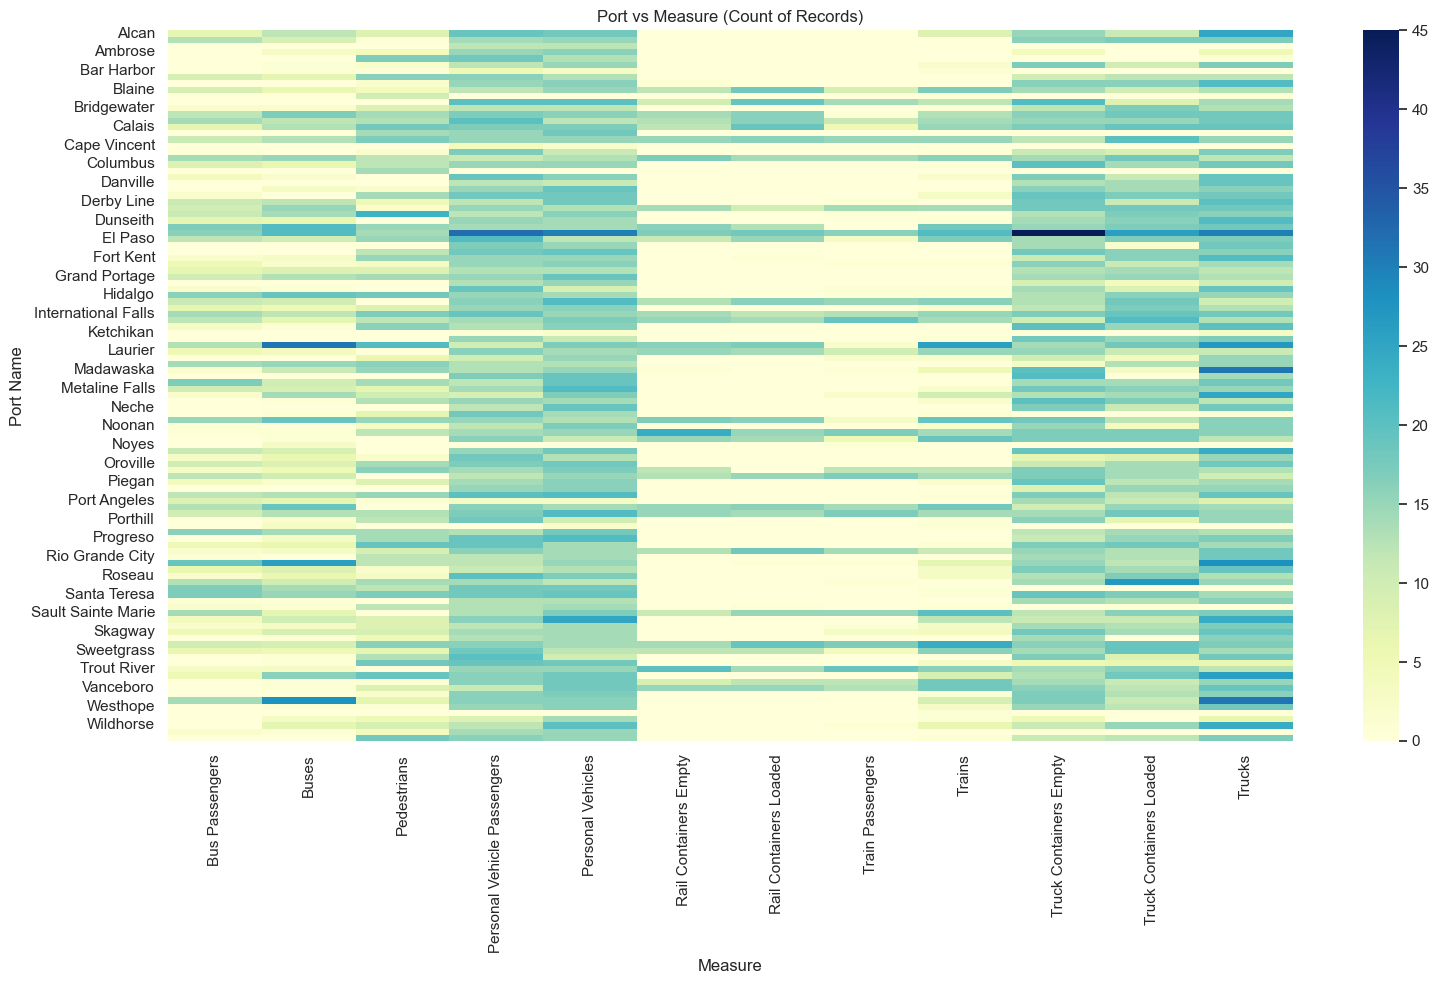

In [43]:

# 5. Port vs Measure Heatmap
pivot_table = pd.pivot_table(df, index='Port Name', columns='Measure', values='Value', aggfunc='count', fill_value=0)
plt.figure(figsize=(16, 10))
sns.heatmap(pivot_table, cmap="YlGnBu")
plt.title("Port vs Measure (Count of Records)")
plt.tight_layout()
plt.show()


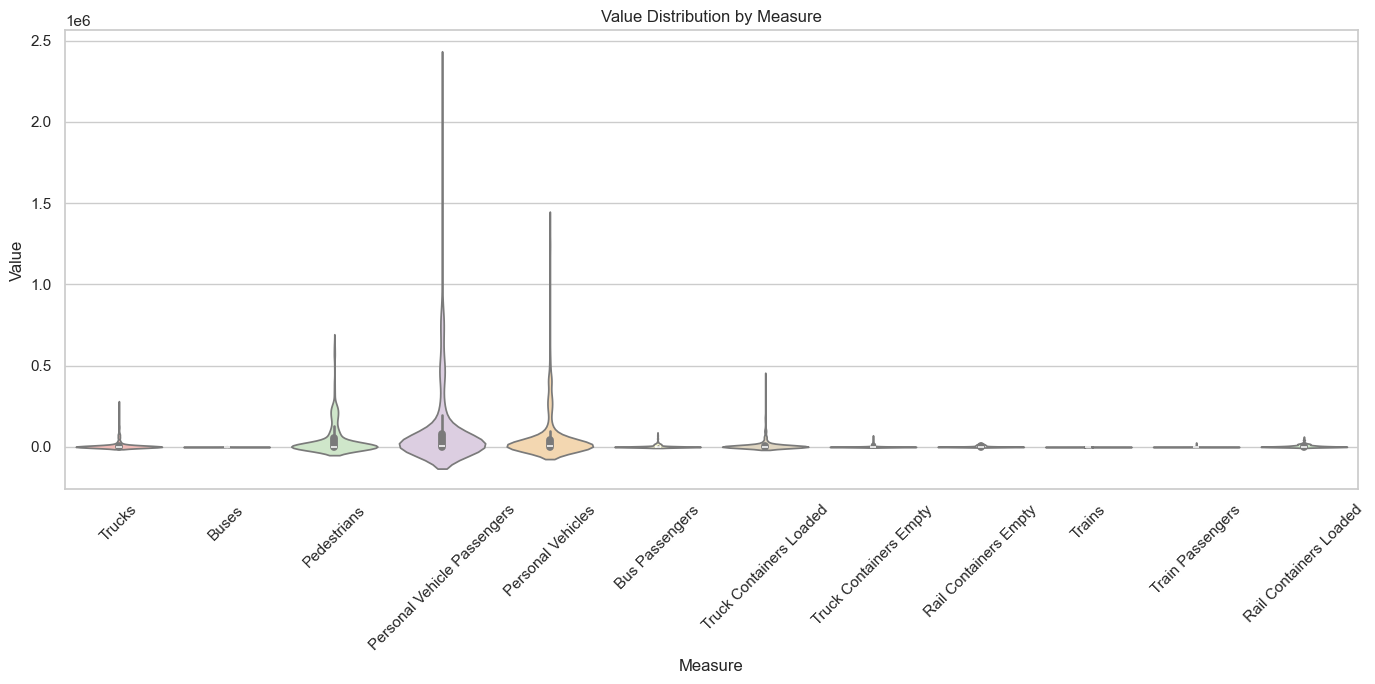

In [44]:

# 6. Value Distribution by Measure (Violin)
plt.figure(figsize=(14, 7))
sns.violinplot(x='Measure', y='Value', data=df, palette='Pastel1', inner='box')
plt.xticks(rotation=45)
plt.title("Value Distribution by Measure")
plt.tight_layout()
plt.show()


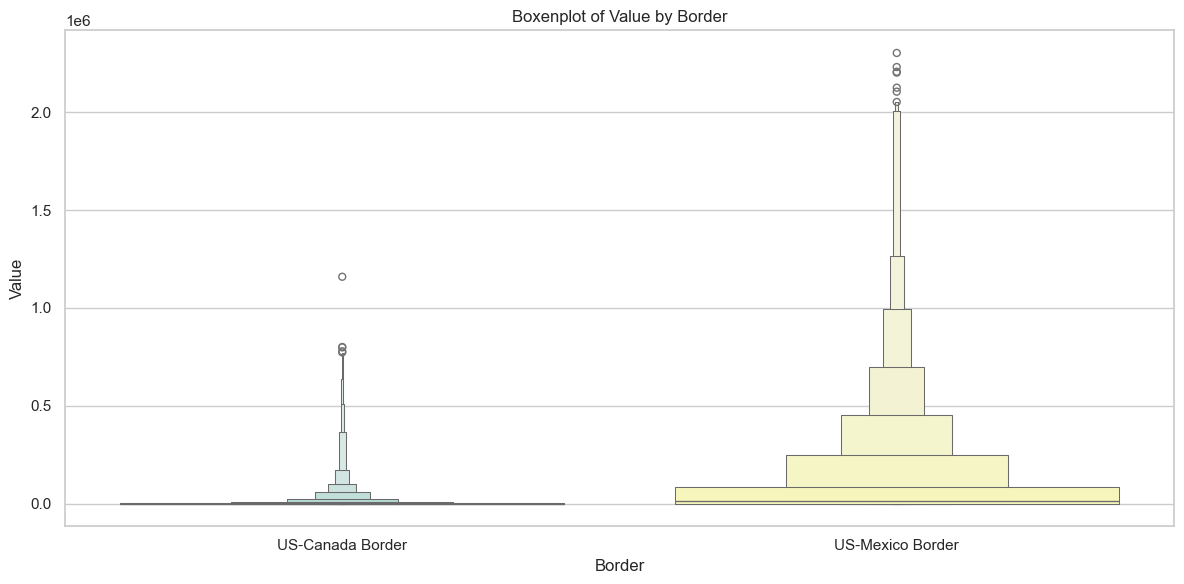

In [45]:

# 7. Boxenplot for Skewed Data
plt.figure(figsize=(12, 6))
sns.boxenplot(x='Border', y='Value', data=df, palette='Set3')
plt.title("Boxenplot of Value by Border")
plt.tight_layout()
plt.show()


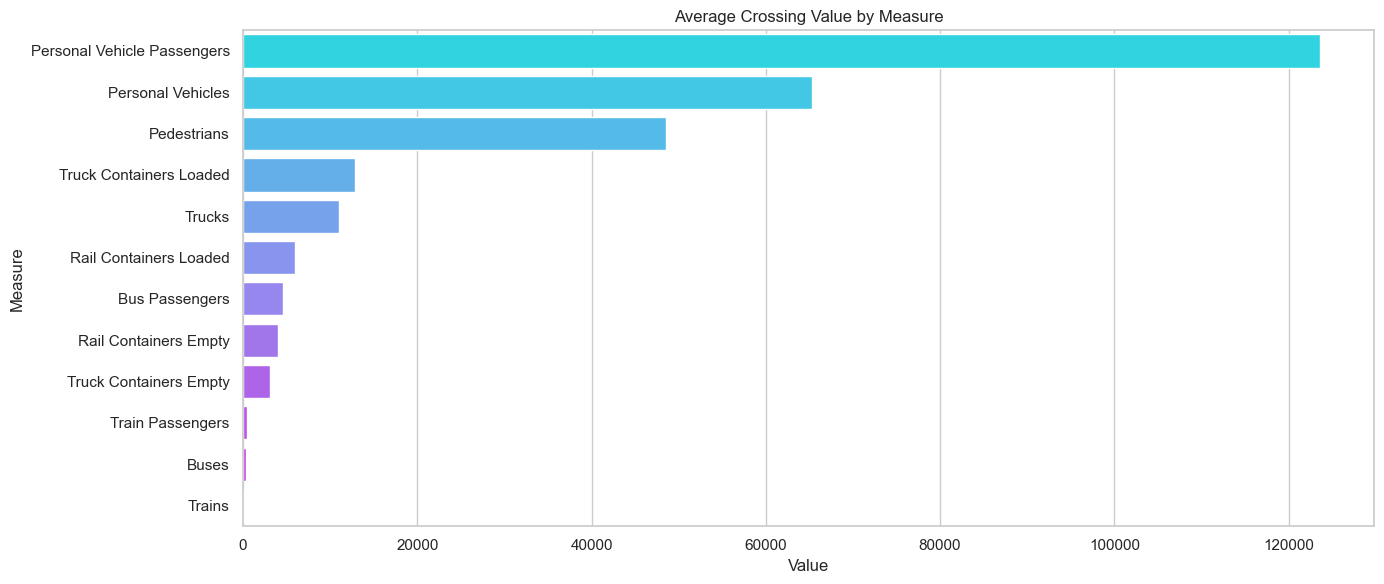

In [46]:

# 11. Average Crossing Value by Measure
avg_measure_value = df.groupby('Measure')['Value'].mean().reset_index().sort_values(by='Value', ascending=False)
plt.figure(figsize=(14, 6))
sns.barplot(x='Value', y='Measure', data=avg_measure_value, palette='cool')
plt.title("Average Crossing Value by Measure")
plt.tight_layout()
plt.show()


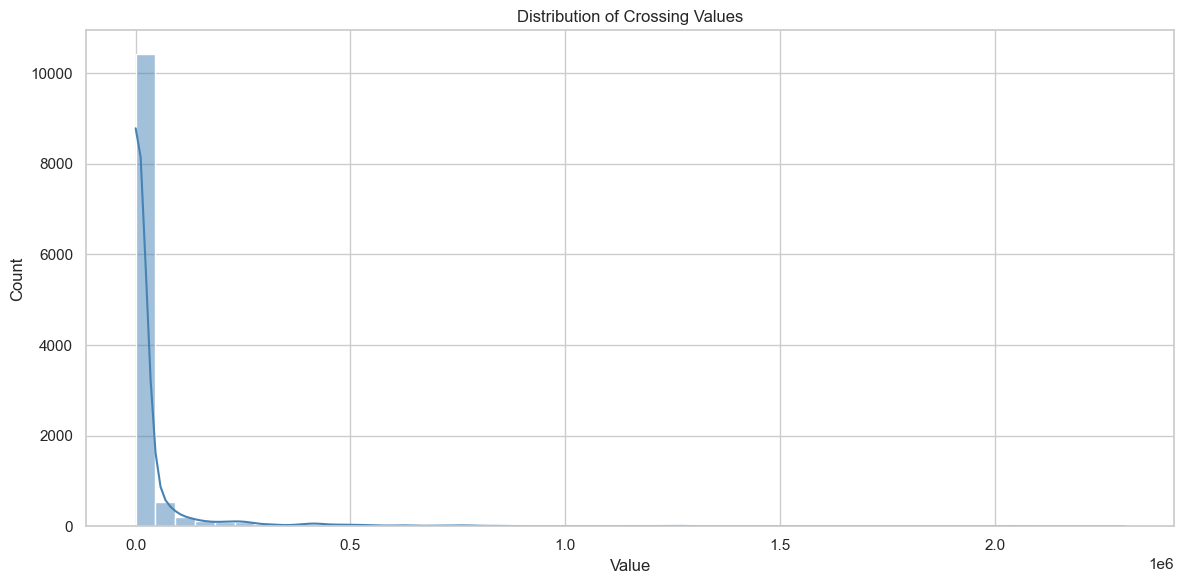

In [47]:

# 12. Distribution Plot for Values
plt.figure(figsize=(12, 6))
sns.histplot(df['Value'], bins=50, kde=True, color='steelblue')
plt.title("Distribution of Crossing Values")
plt.tight_layout()
plt.show()


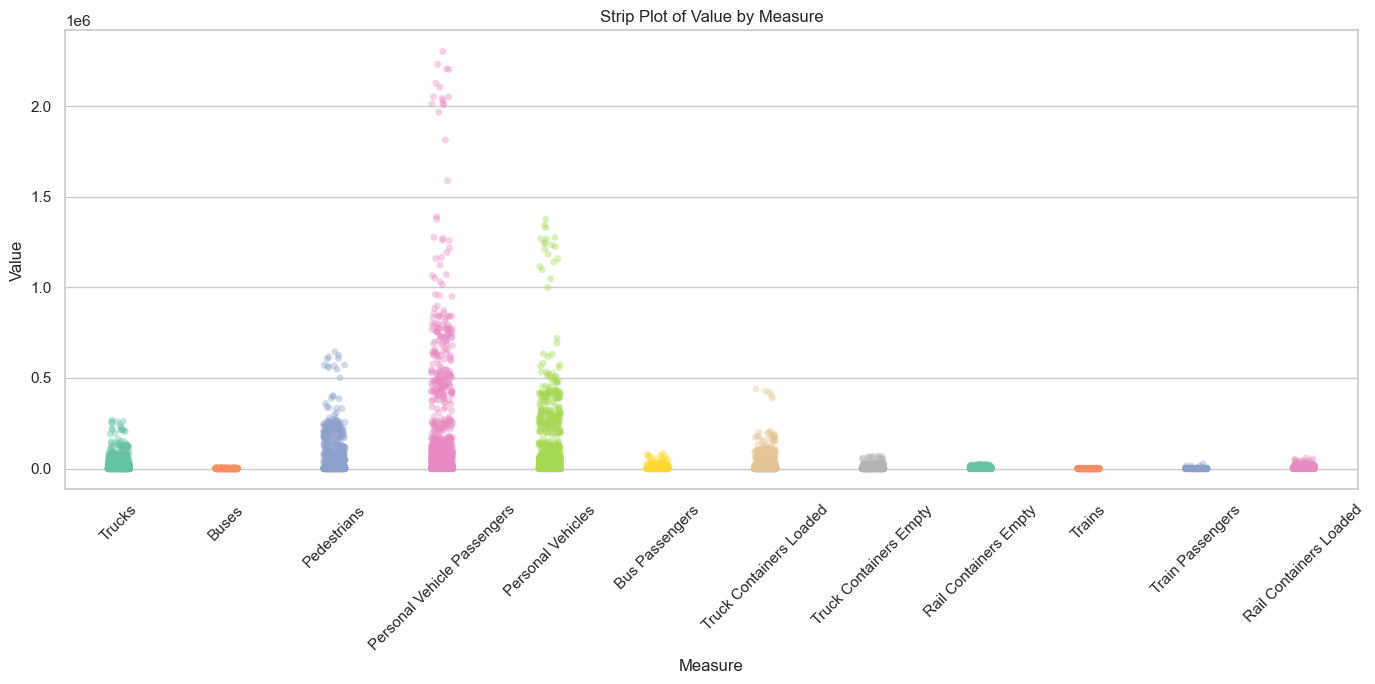

In [48]:

# 14. Strip Plot by Measure
plt.figure(figsize=(14, 7))
sns.stripplot(data=df, x='Measure', y='Value', palette='Set2', alpha=0.4)
plt.xticks(rotation=45)
plt.title("Strip Plot of Value by Measure")
plt.tight_layout()
plt.show()


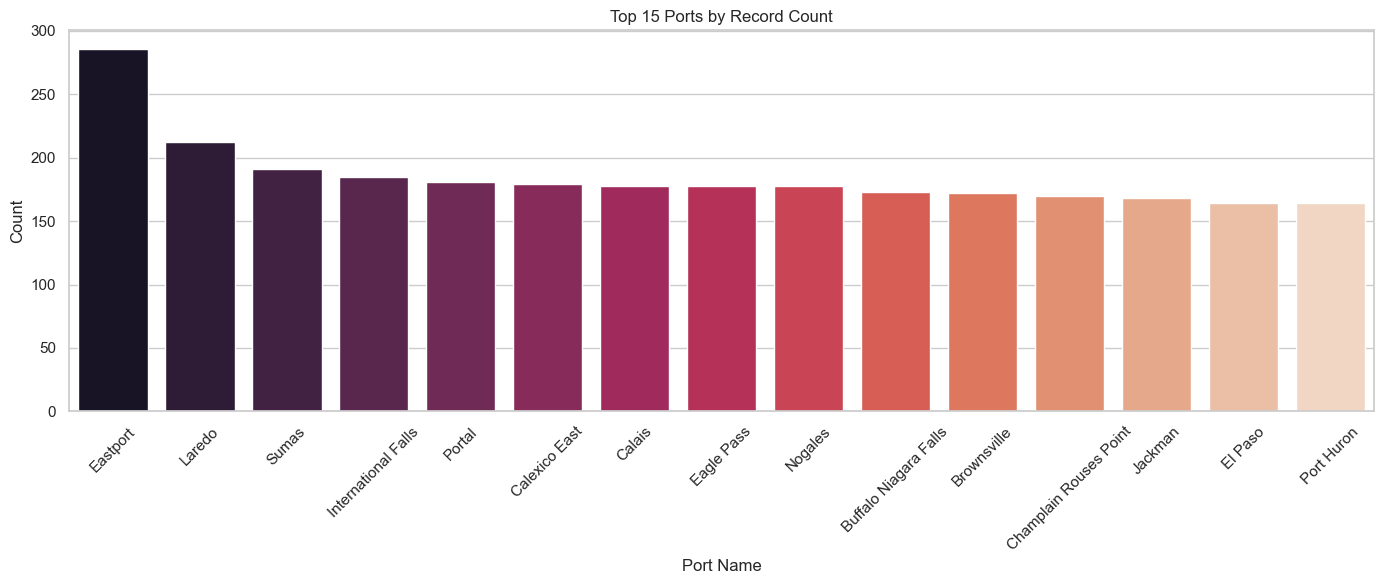

In [49]:

# 15. Count Plot of Port Names
top_ports = df['Port Name'].value_counts().nlargest(15).reset_index()
top_ports.columns = ['Port Name', 'Count']
plt.figure(figsize=(14, 6))
sns.barplot(x='Port Name', y='Count', data=top_ports, palette='rocket')
plt.xticks(rotation=45)
plt.title("Top 15 Ports by Record Count")
plt.tight_layout()
plt.show()


In [50]:

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

print("\nData cleaning, outlier removal using IQR, and visualization completed successfully!")



Summary Statistics:
          Port Code         Value     Latitude     Longitude
count  11839.000000  1.183900e+04  11839.00000  11839.000000
mean    2393.327308  3.373191e+04     43.31401    -98.706346
std     1217.669155  1.345150e+05      8.41333     18.289346
min      101.000000  0.000000e+00     25.95200   -141.001000
25%     2302.000000  8.600000e+01     32.67300   -112.788000
50%     3004.000000  7.030000e+02     46.76500   -100.928000
75%     3323.000000  7.591500e+03     49.00000    -83.048000
max     3814.000000  2.302112e+06     62.61500    -66.980000

Data cleaning, outlier removal using IQR, and visualization completed successfully!
